In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import pandas as pd

In [5]:
data=pd.read_excel("C:\\Users\\palle\\OneDrive\\Desktop\\telco churn\\Telco_customer_churn.xlsx")

In [6]:
data

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
data.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
data.shape

(7043, 33)

In [10]:
data.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [11]:
data['Total Charges'].dtype

dtype('O')

In [12]:
data['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [13]:
data['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
data['Total Charges'].isnull().sum()

np.int64(0)

In [15]:
data["Total Charges"]=pd.to_numeric(data['Total Charges'],errors="coerce")

In [16]:
data

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [17]:
data['Total Charges'].dtype

dtype('float64')

In [18]:
data.drop(['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Reason'],axis=1,inplace=True)

In [19]:
data

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,45,5306
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,59,2140
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,71,5560
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,59,2793


In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le=LabelEncoder()
for col in data.select_dtypes(include="object").columns:
  data[col]=le.fit_transform(data[col])

In [22]:
data

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,86,3239
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,67,2701
2,0,0,0,1,8,1,2,1,0,0,...,2,2,0,1,2,99.65,820.50,1,86,5372
3,0,0,1,1,28,1,2,1,0,0,...,2,2,0,1,2,104.80,3046.05,1,84,5003
4,1,0,0,1,49,1,2,1,0,2,...,2,2,0,1,0,103.70,5036.30,1,89,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,72,1,0,2,1,1,...,1,1,2,1,0,21.15,1419.40,0,45,5306
7039,1,0,1,1,24,1,2,0,2,0,...,2,2,1,1,3,84.80,1990.50,0,59,2140
7040,0,0,1,1,72,1,2,1,0,2,...,2,2,1,1,1,103.20,7362.90,0,71,5560
7041,0,0,1,1,11,0,1,0,2,0,...,0,0,0,1,2,29.60,346.45,0,59,2793


In [23]:
x=data.drop('Churn Value',axis=1)

In [24]:
x

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Score,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,86,3239
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,67,2701
2,0,0,0,1,8,1,2,1,0,0,...,0,2,2,0,1,2,99.65,820.50,86,5372
3,0,0,1,1,28,1,2,1,0,0,...,2,2,2,0,1,2,104.80,3046.05,84,5003
4,1,0,0,1,49,1,2,1,0,2,...,0,2,2,0,1,0,103.70,5036.30,89,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,72,1,0,2,1,1,...,1,1,1,2,1,0,21.15,1419.40,45,5306
7039,1,0,1,1,24,1,2,0,2,0,...,2,2,2,1,1,3,84.80,1990.50,59,2140
7040,0,0,1,1,72,1,2,1,0,2,...,0,2,2,1,1,1,103.20,7362.90,71,5560
7041,0,0,1,1,11,0,1,0,2,0,...,0,0,0,0,1,2,29.60,346.45,59,2793


In [25]:
y=data['Churn Value']

In [27]:
y

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64

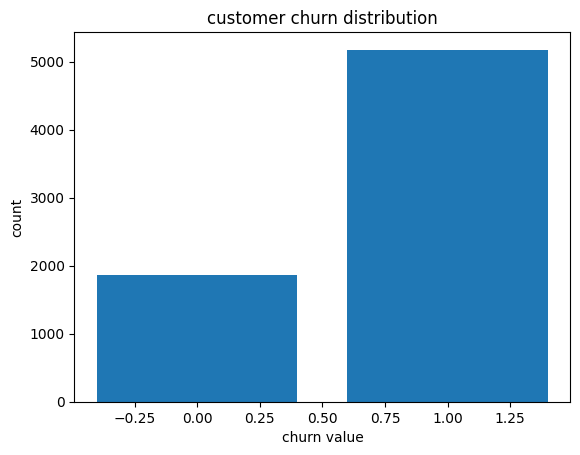

In [28]:

plt.bar(x=data['Churn Value'].unique(),height=data['Churn Value'].value_counts())
plt.title('customer churn distribution')
plt.xlabel('churn value')
plt.ylabel('count')
plt.show()

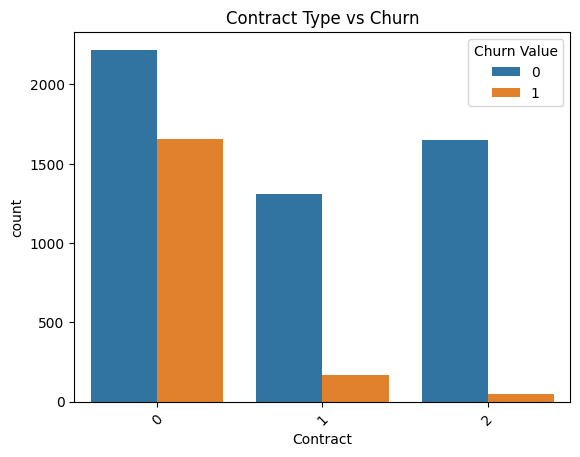

In [29]:
import seaborn as sns

sns.countplot(x='Contract', hue='Churn Value', data=data)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=45)
plt.show()

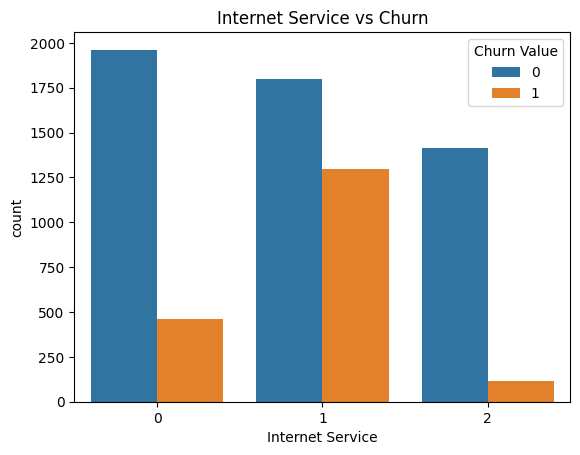

In [30]:
sns.countplot(x='Internet Service', hue='Churn Value', data=data)
plt.title('Internet Service vs Churn')
plt.show()

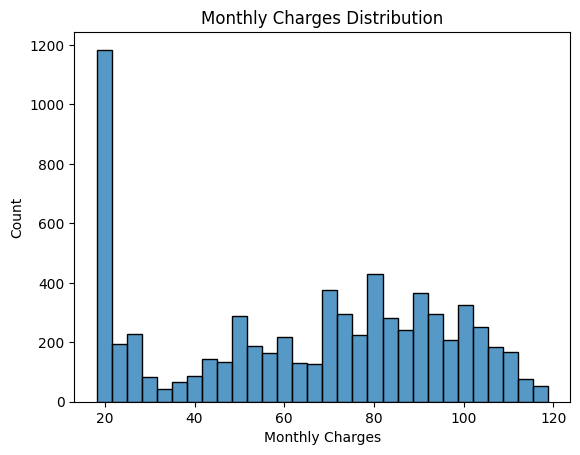

In [31]:
sns.histplot(data['Monthly Charges'], bins=30)
plt.title('Monthly Charges Distribution')
plt.show()

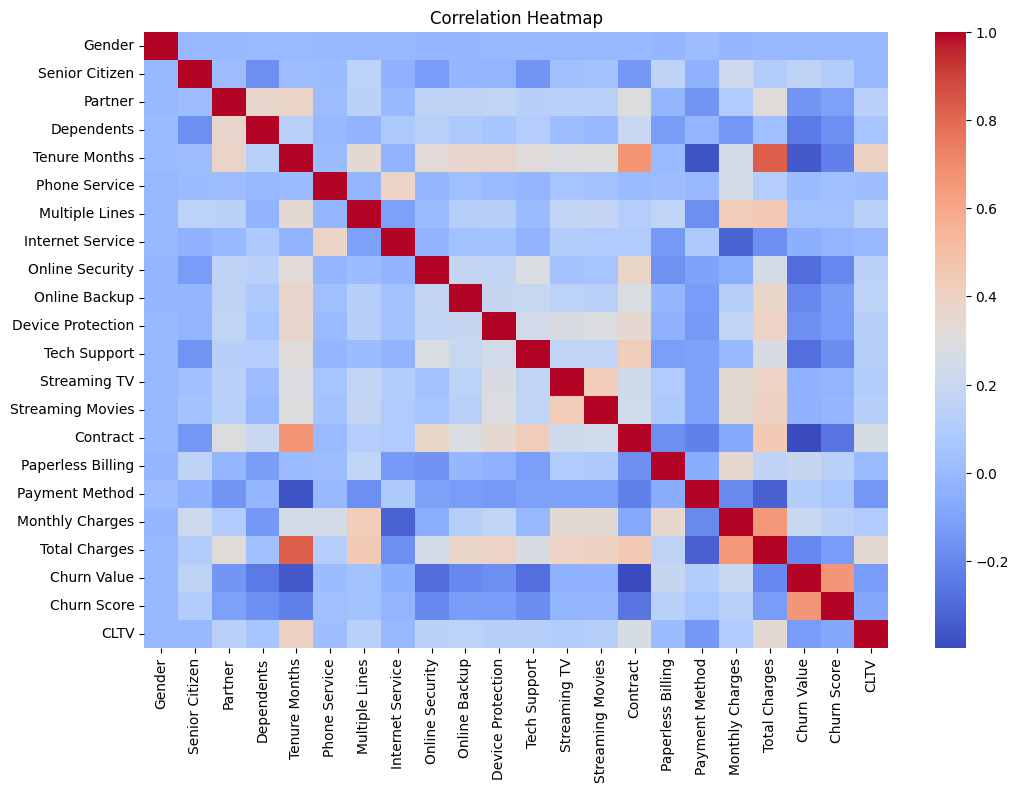

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [33]:
print(data.isnull().sum())

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
Churn Score           0
CLTV                  0
dtype: int64


In [34]:
print(x.isnull().sum())

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Score           0
CLTV                  0
dtype: int64


In [35]:
for col in x.select_dtypes(include=['int64', 'float64']).columns:
    x[col] = x[col].fillna(x[col].median())

In [36]:
for col in x.select_dtypes(include=['object']).columns:
    x[col] = x[col].fillna(x[col].mode()[0])

In [37]:
x.isnull().sum().sum()

np.int64(0)

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score,recall_score,f1_score

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [55]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [56]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled,y_train)
y_pred=lr.predict(x_test_scaled)

In [61]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)


print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9141234918381831
Precision: 0.8444444444444444
Recall   : 0.855
F1 Score : 0.8496894409937888


In [62]:
clf=KNeighborsClassifier()

In [65]:
clf.fit(x_train_scaled,y_train)
y_predi=clf.predict(x_test_scaled)

In [66]:
print("Accuracy :", accuracy_score(y_test, y_predi))
print("Precision:", precision_score(y_test, y_predi))
print("Recall   :", recall_score(y_test, y_predi))
print("F1 Score :", f1_score(y_test, y_predi))

Accuracy : 0.8140525195173882
Precision: 0.6778350515463918
Recall   : 0.6575
F1 Score : 0.6675126903553299


In [67]:
classifier=DecisionTreeClassifier()
classifier.fit(x_train,y_train)
y_predic=classifier.predict(x_test)


In [68]:
print("Accuracy :", accuracy_score(y_test, y_predic))
print("Precision:", precision_score(y_test, y_predic))
print("Recall   :", recall_score(y_test, y_predic))
print("F1 Score :", f1_score(y_test, y_predic))

Accuracy : 0.9020581973030518
Precision: 0.8226600985221675
Recall   : 0.835
F1 Score : 0.8287841191066998


In [69]:
classify=GaussianNB()
classify.fit(x_train,y_train)
y_predict=classify.predict(x_test)

In [70]:
print("Accuracy :", accuracy_score(y_test, y_predict))
print("Precision:", precision_score(y_test, y_predict))
print("Recall   :", recall_score(y_test, y_predict))
print("F1 Score :", f1_score(y_test, y_predict))

Accuracy : 0.8672817601135557
Precision: 0.7330415754923414
Recall   : 0.8375
F1 Score : 0.7817969661610268


In [73]:
svm = SVC()

svm.fit(x_train_scaled, y_train)

y_predicts = svm.predict(x_test_scaled)

In [74]:
print("Accuracy :", accuracy_score(y_test, y_predicts))
print("Precision:", precision_score(y_test, y_predicts))
print("Recall   :", recall_score(y_test, y_predicts))
print("F1 Score :", f1_score(y_test, y_predicts))

Accuracy : 0.9098651525904897
Precision: 0.8491048593350383
Recall   : 0.83
F1 Score : 0.8394437420986094


In [80]:
acc_lr = accuracy_score(y_test, y_pred)
acc_knn = accuracy_score(y_test, y_predi)
acc_dt = accuracy_score(y_test, y_predic)
acc_nb = accuracy_score(y_test, y_predict)
acc_svm = accuracy_score(y_test, y_predicts)

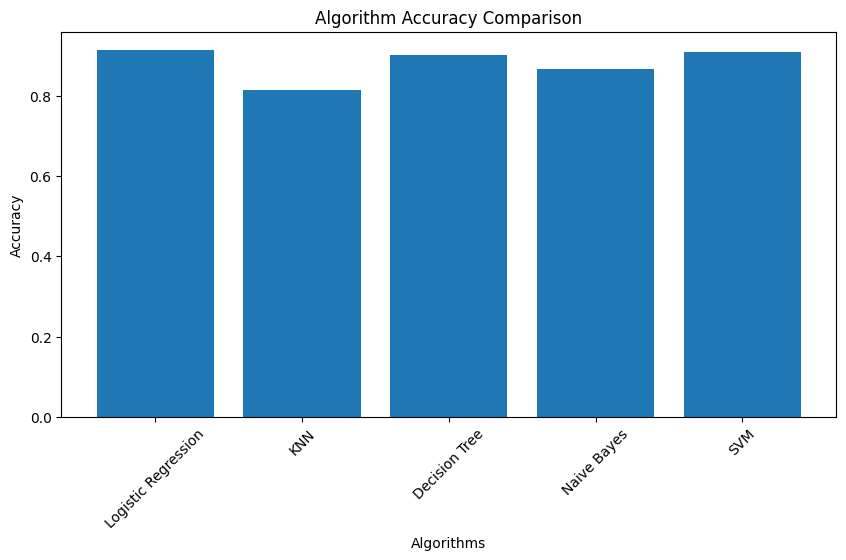

In [83]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'KNN',
    'Decision Tree',
    'Naive Bayes',
    'SVM'
]

accuracies = [
    acc_lr,
    acc_knn,
    acc_dt,
    acc_nb,
    acc_svm
]

plt.figure(figsize=(10,5))
plt.bar(models, accuracies)

plt.title("Algorithm Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

In [40]:


# Models
models = [
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Naive Bayes', GaussianNB()),
    ('SVM', SVC())
]

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Store results
results = []

for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc * 100, 2)
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

c:\Users\palle\OneDrive\Desktop\major project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy
2  Logistic Regression     91.34
1        Decision Tree     90.56
3          Naive Bayes     87.44
0                  KNN     77.36
4                  SVM     73.46


In [44]:
import pickle

# Models to save
models_to_save = [
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Naive Bayes', GaussianNB()),
    ('SVM', SVC())
]

# Dictionary to store all models
all_models = {}

# Train and store each model
for model_name, model in models_to_save:
    model.fit(x_train, y_train)
    all_models[model_name] = model
    print(f"✓ {model_name} model trained")

# Save all models to one file
with open("telco_churn_all_models.pkl", "wb") as file:
    pickle.dump(all_models, file)

print("\nAll models saved in 'telco_churn_all_models.pkl' successfully!")

✓ KNN model trained
✓ Decision Tree model trained


c:\Users\palle\OneDrive\Desktop\major project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✓ Logistic Regression model trained
✓ Naive Bayes model trained
✓ SVM model trained

All models saved in 'telco_churn_all_models.pkl' successfully!
